In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")
from src import *

# Torque target Stochastic Regression

In this notebook we're going to train a `PyKAN`, an `EfficientKAN`, and a `MLP` to learn a function that maps each set of input features to its own probability distribution.

We assume that the underlying process has many small, independent disturbances. Thus, Leveraging the Central limit theorem, we can say that the error between the model's prediction and **the actual observed value is likely to be normal**.

In [2]:
df_x, df_y = read_dataset(stage='regression')
# df_x = df_x[['oat', 'mgt', 'pa ias ng', 'trq_measured_norm_da']]

In [3]:
device = "cuda"

## Train the PyKAN

In [124]:
pyKAN: PHMNetwork = PyKAN(
    [[len(df_x.columns), 0],  [2, 0]],
    "regression",
    grid_size=1,
    k=3,
    device=device,
    use_native_loss=False,
)

checkpoint directory created: ./model
saving model version 0.0


In [88]:
prefix="7-interpretable_extension"

Ok, here goes the training. If you want to repeat the training several times, say 10, with a different random trainset each time, to test the dependence of the training on the trainset selection, change `times` from 1 to 10.

- This will store the metrics results inside the `results/<prefix>.csv` file.
- The means and standard deviations used to standardize the dataset in each training, which values depend on the selected trainset, are stored inside the `results/<prefix>_norm.csv`.

In [ ]:
# 3m
pyKAN.multi_train(
    df_x,
    df_y["trq_margin"],
    epochs=10,
    lr=0.001,
    train_ratio=0.95,
    batch_size=2048,
    prefix=prefix,
    times=1,
)

In [134]:
pyKAN.load(prefix)
_, _, testset, _ = split_dataset(
    df_x,
    df_y["trq_margin"],
    standardize_y=False,
    train_ratio=0.15,
    max=1,
    seed=1,
    device=device,
)
pyKAN.test(testset)

100%|██████████| 51/51 [00:00<00:00, 191.16it/s]


{'test_loss': np.float64(-0.6033719626127505)}

In [90]:
pyKAN.save(prefix)

In [135]:
pyKAN.model=pyKAN.model.prune()

saving model version 0.7


In [130]:
pyKAN.model.remove_node(0,1)

saving model version 0.4
saving model version 0.5
saving model version 0.6


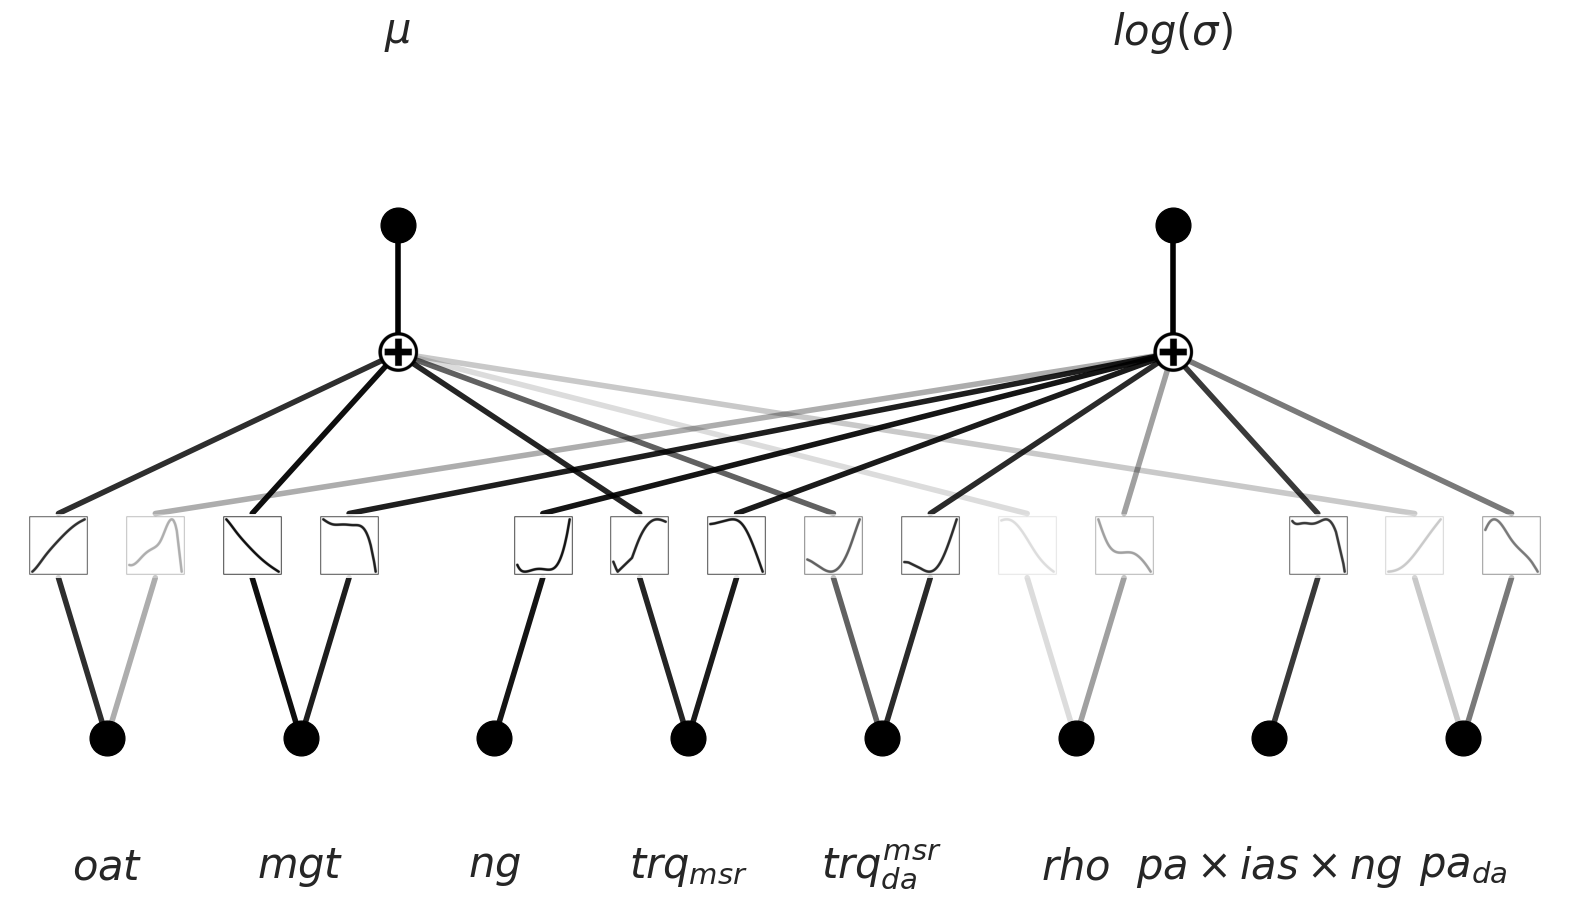

In [136]:
# 1s
pyKAN.plot(scale=2, in_vars=list(map(to_latex, df_x.columns)), varscale=3, rotate_in_vars=True)

In [106]:
pyKAN.model.symbolic_formula()[0][0]

1.0898768901825*(7.49088001251221 - 1.00759983062744*x_2)**2 + 0.0670145899057388*(-6.3360800743103*x_5 - 8.79191970825195)**2 - 70.4606170654297*sin(0.177440017461777*x_1 - 2.55191969871521) - 28.453950881958*sin(0.695599853992462*x_4 - 2.34711980819702) + 2.11702442169189*sin(0.814799845218658*x_6 - 3.57871985435486) - 5.72681951522827*sin(0.476879835128784*x_8 + 8.43688011169434) - 122.661416903138

In [102]:
pyKAN.model.auto_symbolic()

fixing (0,0,0) with sin, r2=0.999834418296814, c=2
fixing (0,0,1) with 0, r2=0.0, c=0
fixing (0,1,0) with x^2, r2=0.9999597072601318, c=2
fixing (0,1,1) with 0, r2=0.0, c=0
fixing (0,2,0) with 0
fixing (0,2,1) with 0, r2=0.0, c=0
fixing (0,3,0) with sin, r2=0.9966995120048523, c=2
fixing (0,3,1) with 0, r2=0.0, c=0
fixing (0,4,0) with 0, r2=0.0, c=0
fixing (0,4,1) with 0, r2=0.0, c=0
fixing (0,5,0) with sin, r2=0.9998366236686707, c=2
fixing (0,5,1) with 0, r2=0.0, c=0
fixing (0,6,0) with 0
fixing (0,6,1) with 0, r2=0.0, c=0
fixing (0,7,0) with sin, r2=0.9999551773071289, c=2
fixing (0,7,1) with 0, r2=0.0, c=0
saving model version 0.3


In [105]:
pyKAN.model.fix_symbolic(0,4,0,'x^2')

r2 is 0.990969717502594
saving model version 0.4


-100000000.0

In [108]:
import re


def process_expression(expr_str, replacements, digits=2):
    def replace_xi(match):
        index = int(match.group(1)) - 1  # Convert to 0-based index
        return replacements[index] if 0 <= index < len(replacements) else match.group(0)
    
    expr_str = re.sub(r'x_(\d+)', replace_xi, expr_str)

    def round_number(match):
        num = float(match.group(0))
        return str(round(num, digits))
    
    expr_str = re.sub(r'-?\d+\.\d+(?:[eE][-+]?\d+)?', round_number, expr_str)
    return expr_str

print(process_expression(str(pyKAN.model.symbolic_formula()[0][0]),list(map(lambda x:to_latex(x).replace('$','').replace("\\\\",'\\'), df_x.columns)),1).replace('**','^').replace('*',''))
# print(process_expression(str(pyKAN.model.symbolic_formula()[0][1]),list(map(lambda x:to_latex(x).replace('$','').replace("\\\\",'\\'), df_x.columns)),2).replace('**','^').replace('*',''))

1.1(7.5 - 1.0mgt)^2 + 0.1(-6.3trq^{msr}_{da} - 8.8)^2 - 70.5sin(0.2oat - 2.6) - 28.5sin(0.7trq_{msr} - 2.3) + 2.1sin(0.8rho - 3.6) - 5.7sin(0.5pa_{da} + 8.4) - 122.7


\begin{cases}
\mu \approx 8oat - 16mgt + 3.6ng + 14trq^{msr}\\
log(\sigma) \approx 2.1log(-1.2oat + 2.3mgt - \dfrac{ng}{2} - 2trq^{msr} + 6) - 3
\end{cases}

### Visualizing the variance of the performance of the 10 trainings

Text(-3.615456994207282, 0.7, '$\\tilde{\\mu}_3$ = 0.184')

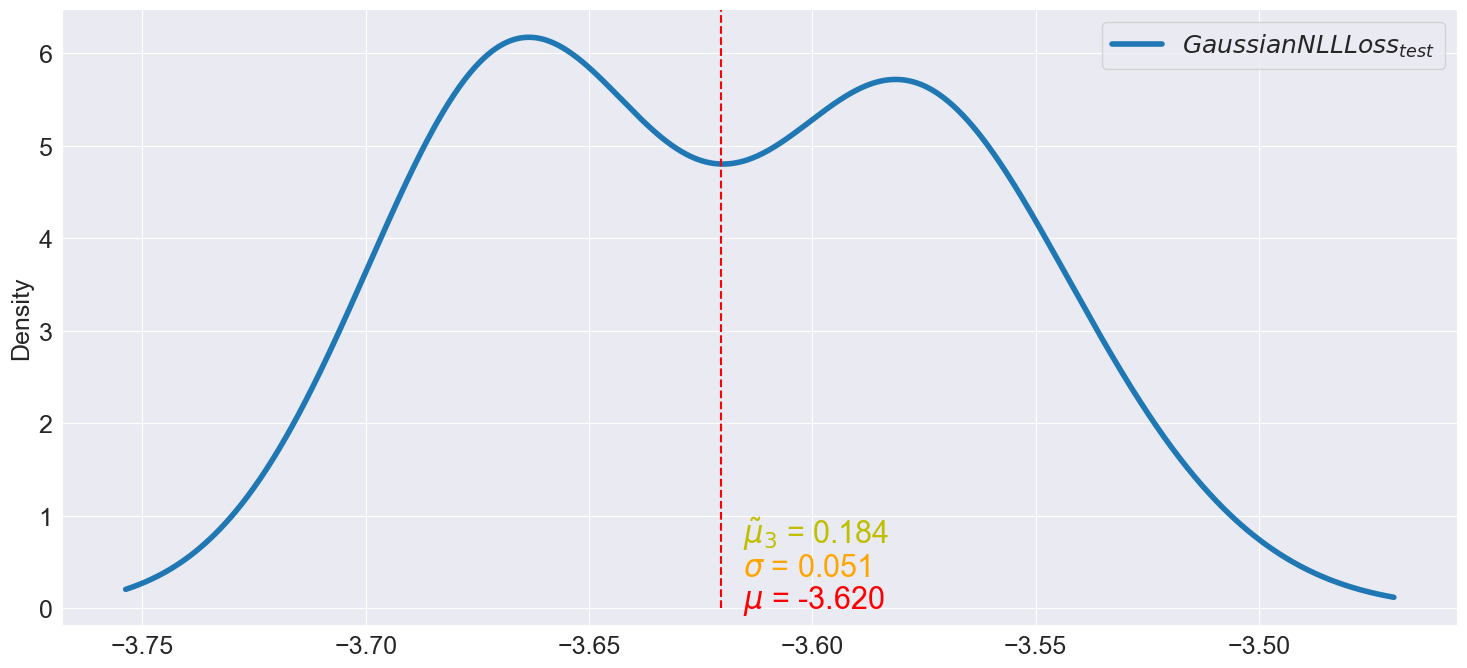

In [19]:
# 0s
result = pd.read_csv(f'results/small_09 March 25 12-23-01.csv').drop('answer_avg_variance', axis=1)
result['training'] = range(1, 11)
ax = result.plot(kind='kde', x='training', y='test_loss', figsize=(18, 8), linewidth=4,
                 label='$GaussianNLLLoss_{test}$')
mean = result['test_loss'].mean()
skew = result['test_loss'].skew()
std = result['test_loss'].std()
ax.add_line(Line2D([mean, mean], [0, 6.5], linestyle='--', color='red'))
ax.text(mean + 0.005, 0, f'$\\mu$ = {mean:.3f}', fontsize=22, c='r')
ax.text(mean + 0.005, 0.35, f'$\\sigma$ = {std:.3f}', fontsize=22, c='orange')
ax.text(mean + 0.005, 0.7, f'$\\tilde{"{"}\\mu{"}"}_3$ = {skew:.3f}', fontsize=22, c='y')

### Plotting an inference

## Train the EfficientKAN

In [13]:
efficientKAN: PHMNetwork = EfficientKAN(layers=[len(df_x.columns), 1, 2], task='regression', device='cpu', use_native_loss=True)

In [10]:
efficientKAN.load('torque_target_final')

In [14]:
# 36s
efficientKAN.multi_train(df_x, df_y['trq_target'], epochs=30, times=1, train_ratio=0.1, batch_size=2048)

Time 1/1===========================


100%|██████████| 54/54 [00:00<00:00, 84.37it/s]


,test_loss
0,4.78247


In [6]:
efficientKAN.save('torque_target_final')

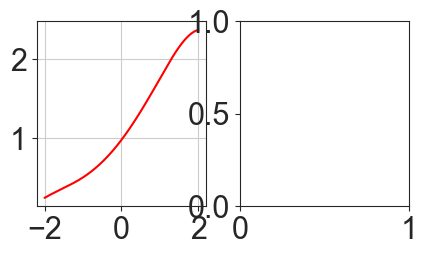

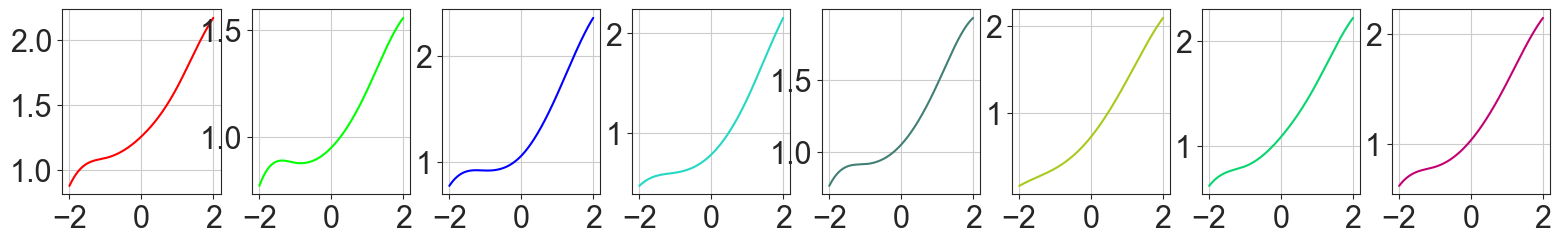

In [15]:
efficientKAN.plot(scale=1.2)

## Train the MLP

In [77]:
mlp: PHMNetwork = MLP(
    layers=[8, 4, 4, 2],
    task="regression",
    device=device,
    use_native_loss=False,
)

In [9]:
mlp.load('6-interpretable')

In [78]:
# 36s
mlp.multi_train(df_x, df_y['trq_margin'], epochs=150, lr=0.05, times=1, batch_size=2048)

Time 1/1===========================


100%|██████████| 45/45 [00:00<00:00, 1107.58it/s]


,test_loss
0,-0.905187


In [22]:
mlp.save('6-interpretable')

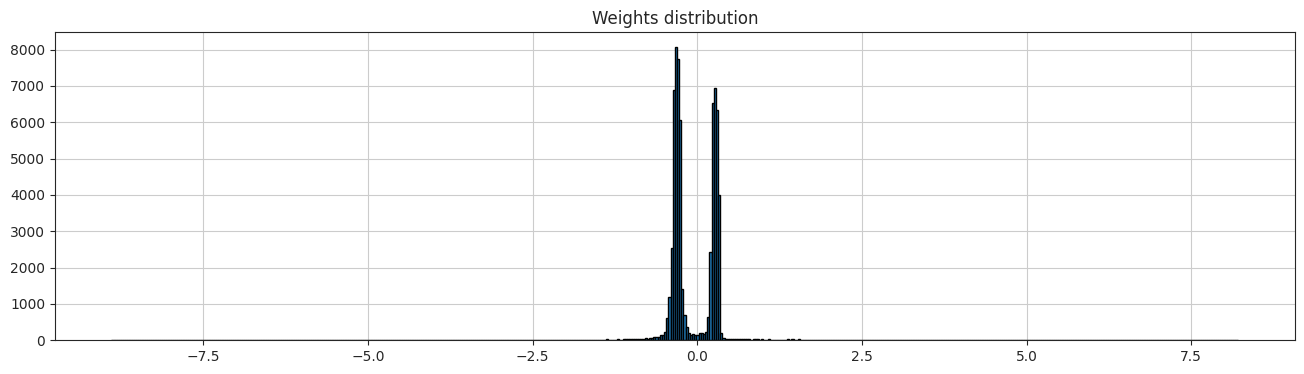

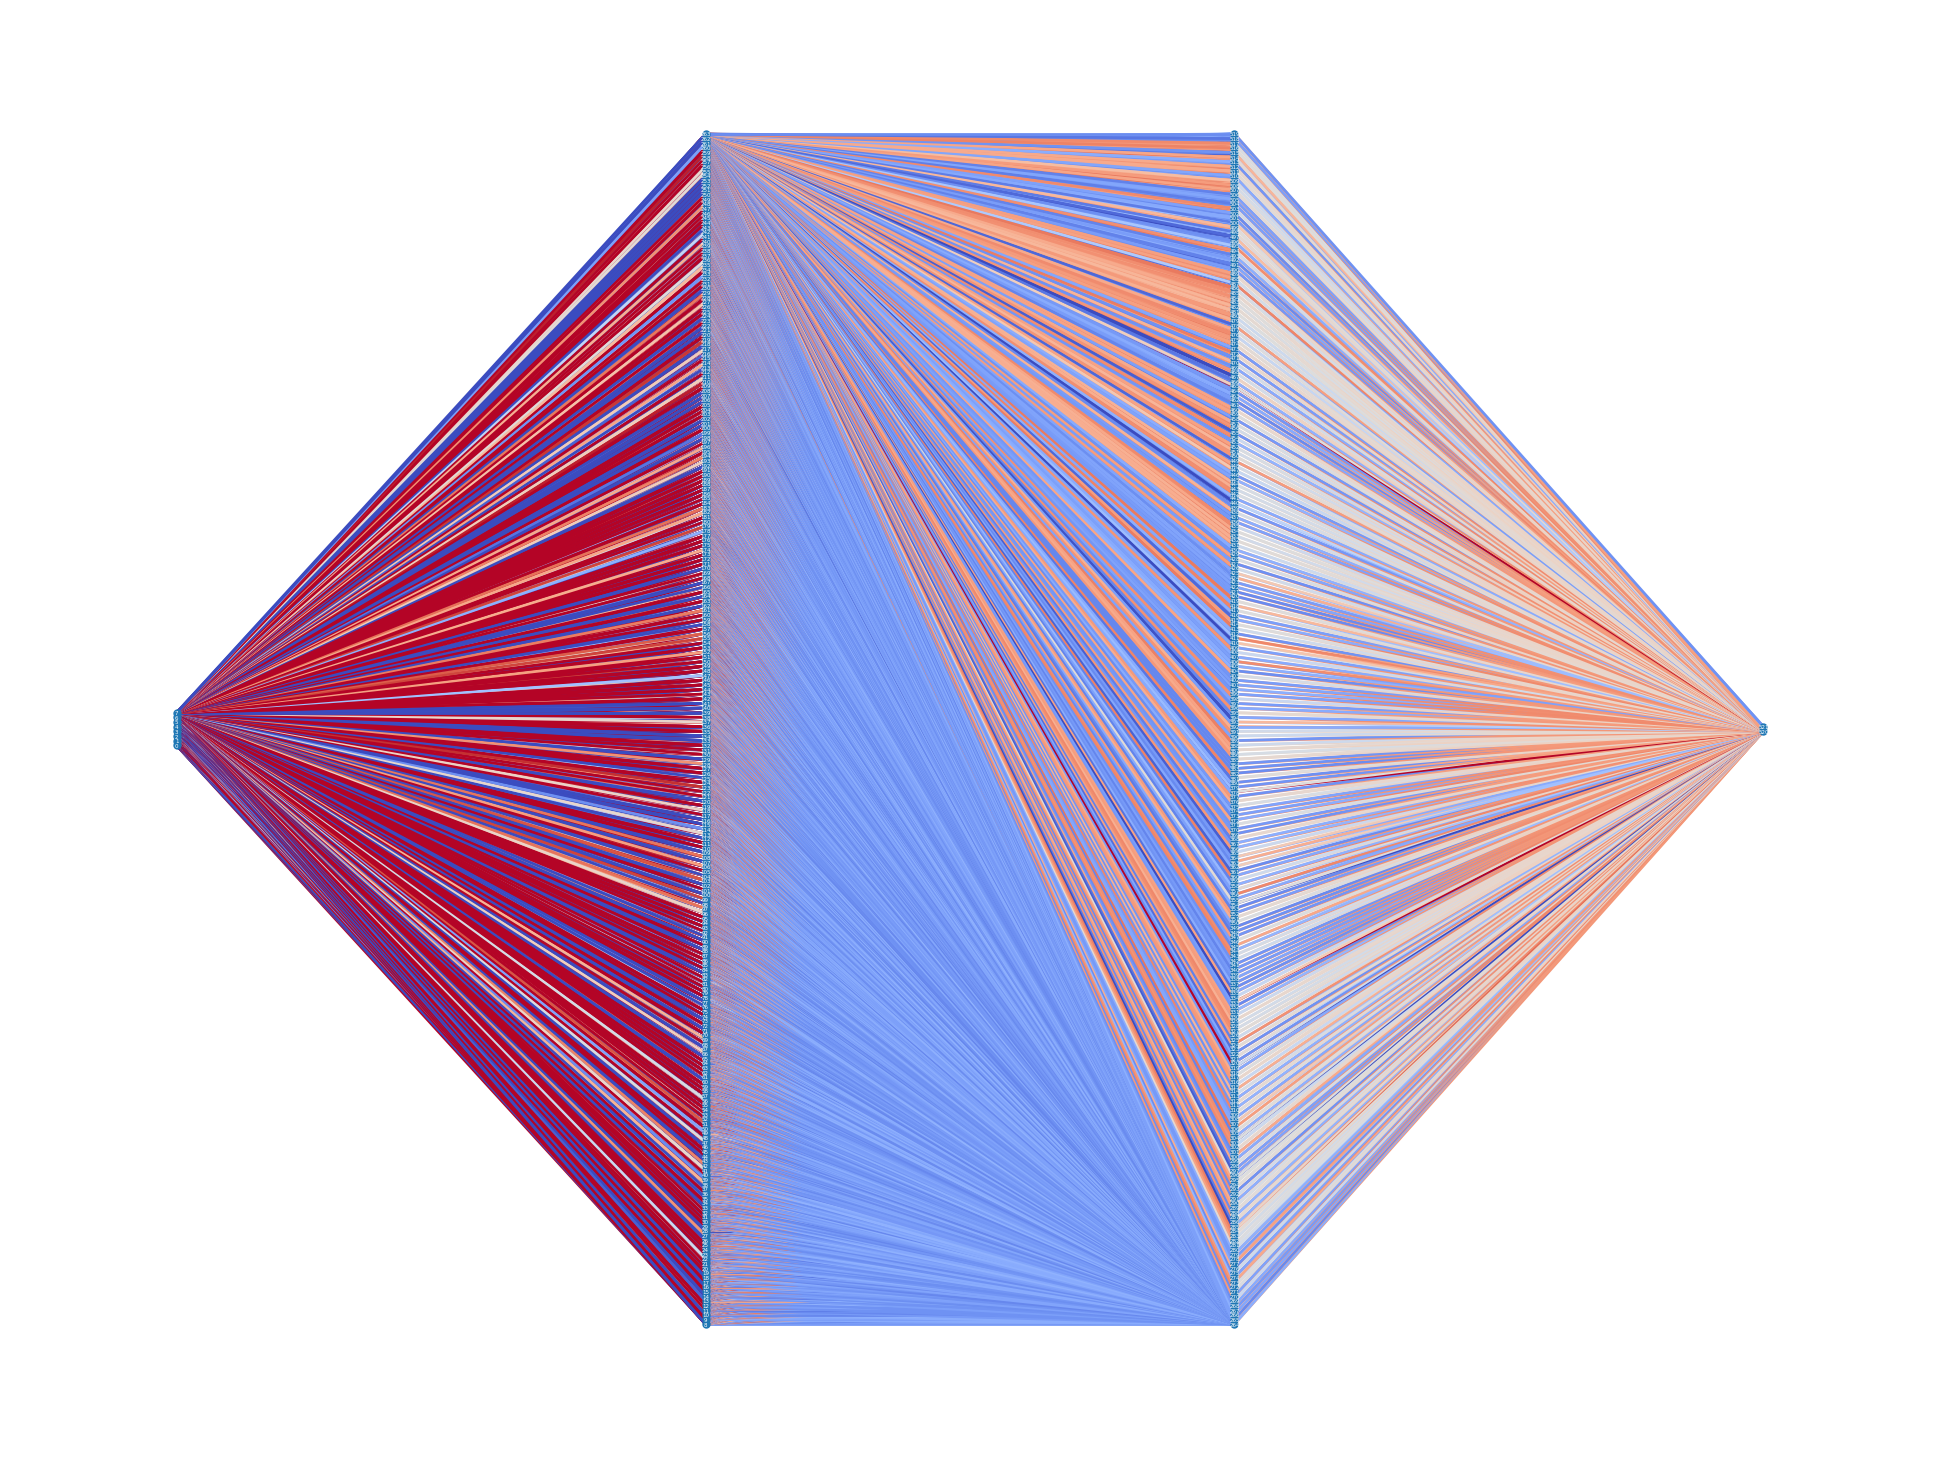

In [ ]:
mlp.plot(scale=1.2, node_size=25, font_size=4, edge_width=1, use_abs=False, vmax=0.5)

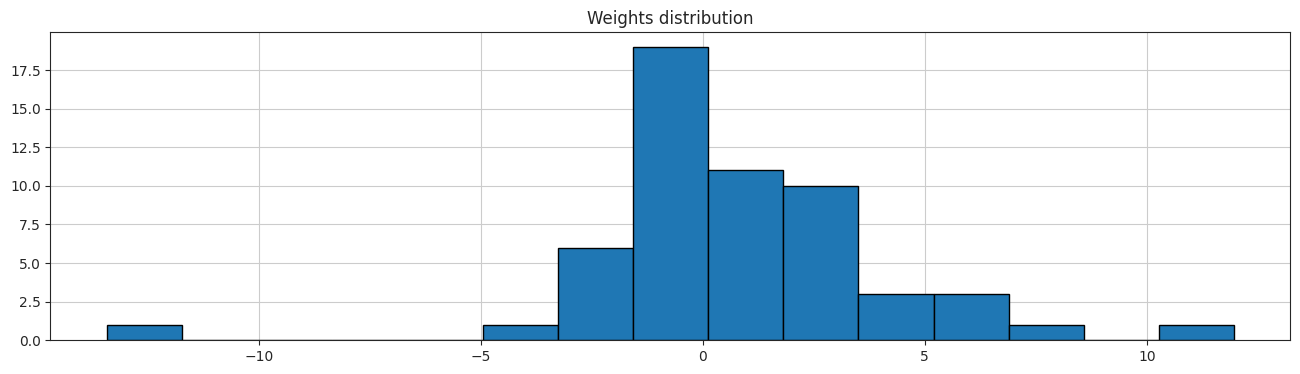

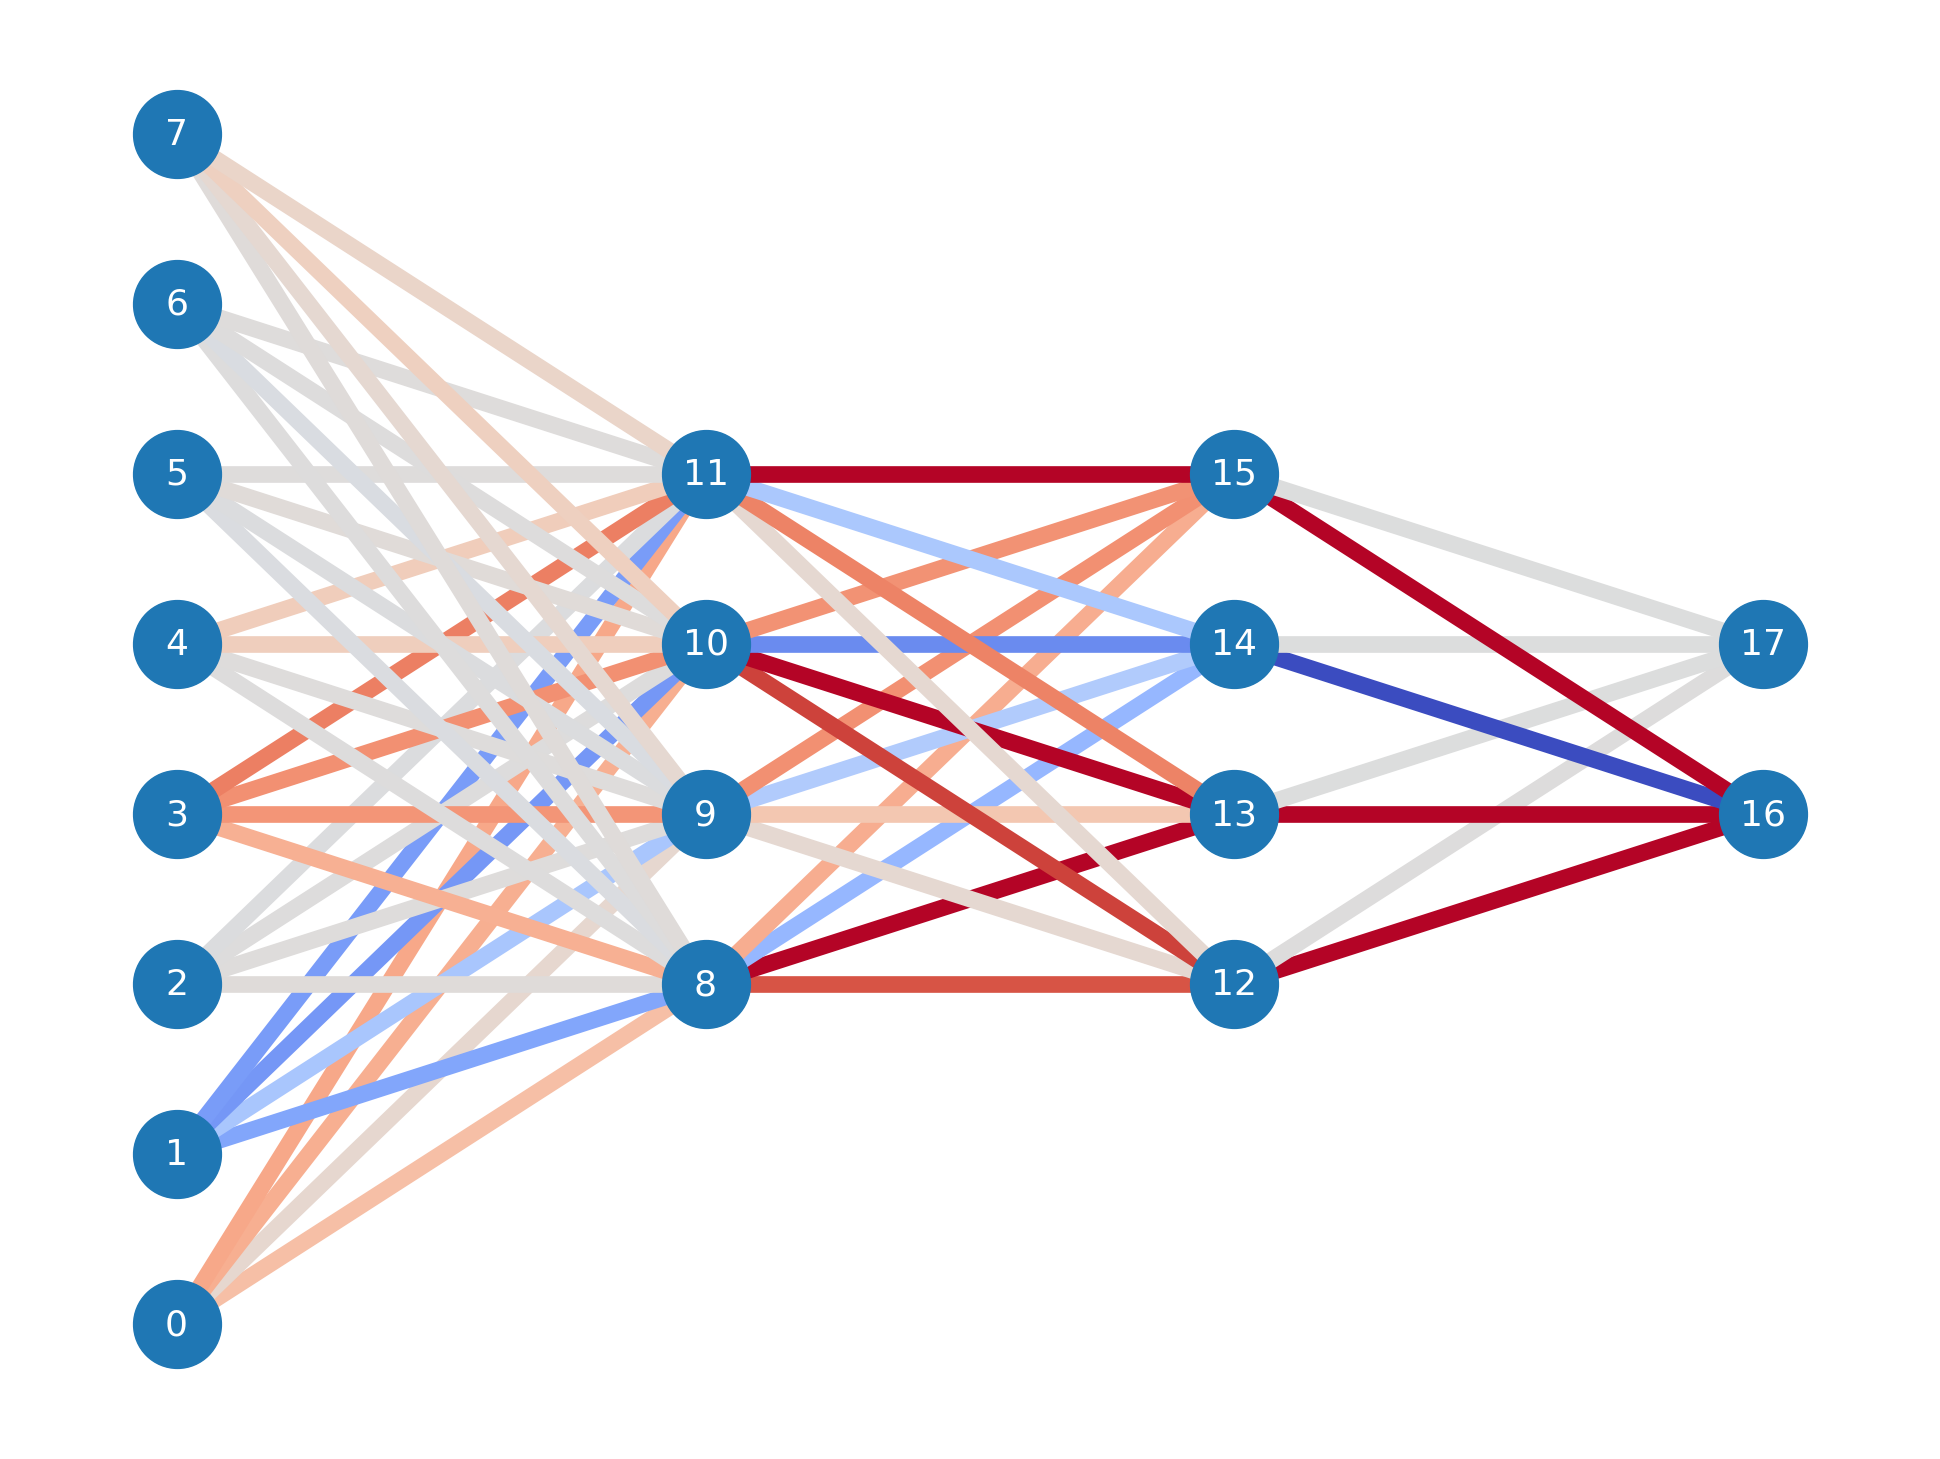

In [79]:
mlp.plot(scale=1.2, node_size=4000, font_size=26, edge_width=12, use_abs=False, vmax=5)

Talk about interpretability... MLP might be accurate, but are far less expressive than KAN!

### FLOPS calculation
See more on: https://arxiv.org/abs/2409.13550

In [ ]:
effKAN1 = EfficientKAN([len(df_x.columns), 1, 1], 'classification', grid_size=2)
mlp1 = MLP([len(df_x.columns), 4, 4, 1], 'classification')

for net in [effKAN1, mlp1]:
    flops, params = get_model_complexity_info(net, (len(df_x.columns),), as_strings=True,
                                              print_per_layer_stat=False)
    print(f"[{net.__class__.__name__}] FLOPs: {flops} | Params: {params}")

[EfficientKAN] FLOPs: 8 Mac | Params: 56
[MLP] FLOPs: 61 Mac | Params: 61


In [86]:
with torch.cuda.device(0):
    flops, params = get_model_complexity_info(mlp, (len(df_x.columns),), as_strings=True)
    print(f"FLOPs: {flops}")
    print(f"Params: {params}")

MLP(
  66, 100.000% Params, 66.0 Mac, 100.000% MACs, 
  (model): Sequential(
    66, 100.000% Params, 66.0 Mac, 100.000% MACs, 
    (0): Linear(36, 54.545% Params, 36.0 Mac, 54.545% MACs, in_features=8, out_features=4, bias=True)
    (1): Sigmoid(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (2): Linear(20, 30.303% Params, 20.0 Mac, 30.303% MACs, in_features=4, out_features=4, bias=True)
    (3): Sigmoid(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (4): Linear(10, 15.152% Params, 10.0 Mac, 15.152% MACs, in_features=4, out_features=2, bias=True)
  )
)
FLOPs: 66 Mac
Params: 66
